# KAN-CDSCO2004U  Machine Learning and Deep Learning

## Lab 8: Stochastic Gradient Descent — ✅ Solution
**Estimated time: 1 hour**

### Learning Objectives
By the end of this exercise, you will be able to:
- Perform **Simple Linear Regression** from scratch
- Build a **Stochastic Gradient Descent** from scratch
- Apply it to the **California housing dataset**

**How to work through this notebook:**
- 🏃 **RUN** cells = Just execute the code to see the output
- ✏️ **TODO** cells = Write your own code or answer questions
- 📖 **READ** cells = Explanations to help you understand the concepts

## <center> Lecture-08 "Stochastic Gradient Descent"

📖 **READ**

# Build Stochastic Gradient Descent, Gradient Descent From Linear Regression on California housing dataset [From scratch]

🏃 **RUN**

- Will use California housing dataset. Data is quite sparse, but we can still observe some linearity.
- Perform a linear regression to predict apartment prices based on the median income in the block. 
- We will start from the simple linear regression and gradually finish with Stochastic Gradient Descent.

In [ ]:
# Import Libraries
# Author: Luca Gudi (lgg.digi@cbs.dk)
# code src: Arseny Turin
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `import [module]` | Imports a Python module/library so we can use its functions. |
| `as [alias]` | Gives the imported library a shorter nickname. For example, `import numpy as np` means we can just type `np.` instead of `numpy.` every time we want to use it. |
| `from [module] import [func]` | Imports only a specific function or class from a library, saving memory and keeping the code clean. |


In [5]:
# Import California Housing Dataset from SkLearn and Store it in a Variable
from sklearn.datasets import fetch_california_housing
housing_data = fetch_california_housing()

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `import [module]` | Imports a Python module/library so we can use its functions. |
| `as [alias]` | Gives the imported library a shorter nickname. For example, `import numpy as np` means we can just type `np.` instead of `numpy.` every time we want to use it. |
| `from [module] import [func]` | Imports only a specific function or class from a library, saving memory and keeping the code clean. |
| `fetch_california_housing()` | A built-in scikit-learn function that downloads the California housing dataset. |
| `housing_data = ...` | `housing_data` acts as a variable storing the downloaded dataset object, which contains the data matrix andfeature names. |


In [6]:
# Build Features and Target Dataframe 
Features = pd.DataFrame(housing_data.data, columns=housing_data.feature_names)
Target = pd.DataFrame(housing_data.target, columns=['Target'])

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `pd.DataFrame(...)` | The `DataFrame` constructor from the `pandas` library. It converts 2D arrays or dictionaries into a tabular DataFrame, making it much easier to view and manipulate like an Excel spreadsheeet. |
| `housing_data.data` | Accesses the 'data' attribute of the dataset, representing the input features. |
| `columns=` | A parameter passed to `DataFrame` specifying the names of the columns. If omitted, pandas would just name them 0, 1, 2, etc. |
| `housing_data.target` | Accesses the target variable (the values we want to predict). |
| `['Target']` | A Python list containing a single string 'Target', used to explicitly name the single column in the Target dataframe. |


In [7]:
# Build One Joined Dataframe and Look at the Correlation Values
df = Features.join(Target)
df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
Target,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| *(General Code)* | Implements the formula or logic defined in the preceding markdown text. |


🏃 **RUN**

## Preprocessing: Removing Outliers

- `Target` and `MedInc` has outliers, because 75% of the data has price less than 2.65, but maximum price go as high as 5. 
- Remove extremely expensive houses.

In [9]:
# Get an Overview of the columns 'MedInc' (Median Income) and 'Target'
df[['MedInc', 'Target']].describe()[1:]

,MedInc,Target
mean,3.870671,2.068558
std,1.899822,1.153956
min,0.499900,0.149990
25%,2.563400,1.196000
50%,3.534800,1.797000
75%,4.743250,2.647250
max,15.000100,5.000010


### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| *(General Code)* | Implements the formula or logic defined in the preceding markdown text. |


In [10]:
# Remove the extremely expensive houses
df = df[df.Target < 3.5]
df = df[df.MedInc < 8]

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `df.Target < 3.5` | Creates a boolean mask (a list of True/False values). For each row, it checks if the 'Target' value is less than 3.5. |
| `df[...]` | We pass the True/False mask back into the DataFrame using brackets. This filters the DataFrame, keeping only the rows where the mask is True. |
| `.reset_index()` | After filtering rows out, the old row indices (e.g. 0, 1, 3, 7...) are kept intact. `reset_index` resets them to a clean 0, 1, 2, 3 sequence. |
| `drop=True` | A parameter for `reset_index`. If `True`, it drops the old index entirely. If `False` (the default), it inserts the old index as a new column in the DataFrame, which we usually don't want. |


---

## 4. Stage-01 -- Develop Simple Linear Regression from Scratch

📖 **READ**

We start with a basic Single-variable Linear Regression model.

📖 **READ**

Simple linear regression can be described by only two parameters: slope `m` and intercept `b`. Lets take a look at the formulas below:

✏️ **TODO**

### 1. Slope Calculation

The slope \( m \) is calculated using the formula:

$m = \frac{\overline{X} \overline{Y} - \overline{XY}}{\overline{X^2} - (\overline{X})^2}$

Where $ \bar{X} $ is the mean of $ X $, and $ \bar{y} $ is the mean of $ y $

### 2. Intercept Calculation

The intercept \( b \) is calculated as:

$b = \overline{y} - m \times \overline{X}$

### 3. Predictions

Predicted \( y \) values are found using:

$y_{\text{pred}} = mX + b$

### 4. Mean Squared Error (MSE)

MSE measures the goodness of fit of the line:

1. Error calculation: $\text{error} = y - y_{\text{pred}}$
2. Squared error: $\text{squared\_error} = (\text{error})^2$
3. Mean Squared Error: $MSE = \frac{\sum (\text{squared\_error})}{\text{total number of data points}}$

In [14]:
# [TODO] use MedInc` and `Target` variable to build X and y
X = df.MedInc
y = df.Target

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| *(General Code)* | Implements the formula or logic defined in the preceding markdown text. |


In [15]:
# Step 1: Calculate slope and intercept
m = ((np.mean(X) * np.mean(y) - np.mean(X*y)) / ((np.mean(X)**2) - np.mean(X**2)))
b = np.mean(y) - m * np.mean(X)

# Step 2: Calculate predicted y values using the linear regression equation
y_pred = m * X + b

# Step 3: Calculate MSE from scratch and print it
error = y - y_pred
squared_error = error ** 2
mse = sum(squared_error) / len(squared_error)
print("MSE:", mse)


MSE: 0.3432052150225597


### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `error = ...` | Calculates the residuals (difference between true y and predicted y). |
| `** 2` | The Python operator for exponentiation. `** 2` squares the values. We square errors so that negative errors and positive errors don't cancel each other out when we sum them. |
| `sum(...)` | Sums all the values in an array/list. |
| `len(...)` | Returns the total number of items in an array. By dividing the sum of squared errors by the length, we get the 'Mean' Squared Error. |


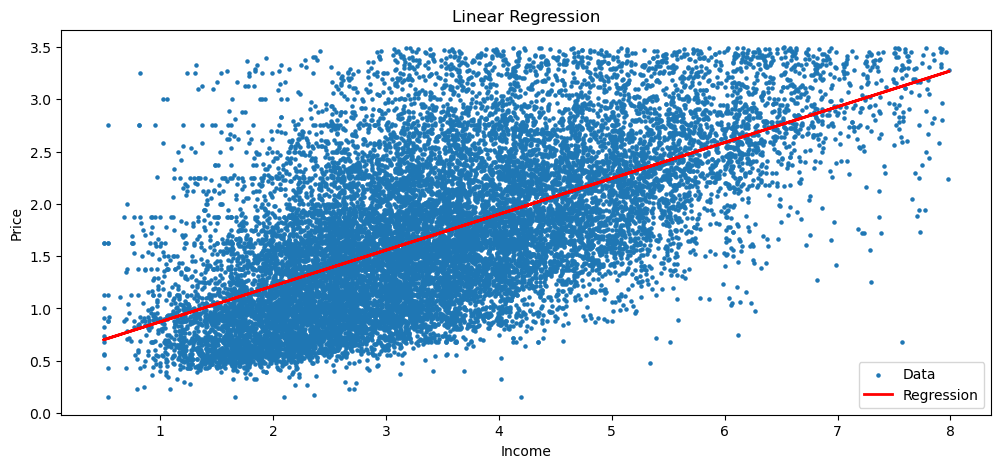

In [16]:
# Plot the results
plt.figure(figsize=(12,5))
plt.scatter(X, y, label='Data', s=5)
plt.plot(X, y_pred, 'r', lw=2, label='Regression')
plt.title("Linear Regression")
plt.xlabel('Income')
plt.ylabel('Price')
plt.legend()
plt.show()

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `plt.scatter(x, y)` | Calls the `scatter` function from Matplotlib's `pyplot` module to create a scatter plot. The first argument is the X-axis array, the second is the Y-axis. |
| `plt.xlabel(...)` | Sets the text label for the X-axis. |
| `plt.ylabel(...)` | Sets the text label for the Y-axis. |
| `plt.title(...)` | Sets the title text displayed at the top of the plot. |
| `plt.show()` | Actually renders and displays the plot to the screen. In Jupyter, plots often render automatically, but explicitly calling `show()` suppresses messy object output texts. |


---

## 5. Stage-02 -- Stochastic Gradient Descent from Scratch

📖 **READ**

Now we will implement SGD.

✏️ **TODO**

When using gradient descent we want to update our `m` and  `b` parameters by using the formula of partial derivative of the loss function. The derivative respect to  `m`  is:
$$\frac{\partial L}{\partial m}=\frac{-2}{n}\sum^n_{i=0}x_i(y_i-\bar{y_i})$$
And the derivative with respect to  `b`:
$$\frac{\partial L}{\partial b}=\frac{-2}{n}\sum^n_{i=0}(y_i-\bar{y_i})$$

The partial derivatives of the loss function with respect to `m` and `b` give us the gradient, which points in the direction of the steepest increase of the loss function. By moving in the opposite direction (i.e., descending), we aim to reduce the loss. Specifically, the partial derivative with respect to `m` indicates how the loss changes with a small change in `m`, and similarly for `b`. The learning rate determines the size of the steps we take along this gradient towards the minimum - this is the reason why we multiply the derivative with the learning rate in the code. If the learning rate is too large, we might overshoot the minimum; if it's too small, the convergence might be very slow.

In [19]:
# Set the parameters lr=0.01, epoch=100, m = 0.2 and b = 0.2

# Set the m, b parameters
m_gd, b_gd = 0.2, 0.2

# Build a list to store learning process
log_gd, mse_gd = [], []

N = len(X)

for epoch in range(100):                
    error = y - (m_gd*X + b_gd)
    m_gd -= 0.01 * -2 * X.dot(error).sum() / N
    b_gd -= 0.01 * -2 * error.sum() / N
    
    log_gd.append((m_gd, b_gd))
    mse_gd.append(mean_squared_error(y, m_gd*X + b_gd))

y_pred_gd = m_gd * X + b_gd

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `error = ...` | Calculates the residuals (difference between true y and predicted y). |
| `** 2` | The Python operator for exponentiation. `** 2` squares the values. We square errors so that negative errors and positive errors don't cancel each other out when we sum them. |
| `sum(...)` | Sums all the values in an array/list. |
| `len(...)` | Returns the total number of items in an array. By dividing the sum of squared errors by the length, we get the 'Mean' Squared Error. |


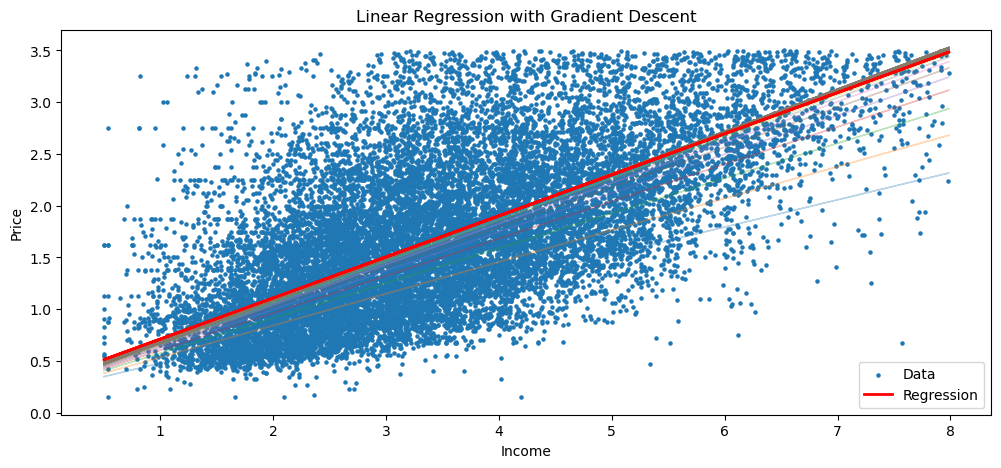

GD MSE: 0.3493097403876614


In [20]:
# Plot gradient descent results
plt.figure(figsize=(12,5))
plt.scatter(X, y, label='Data', s=5)
for i in range(len(log_gd)):
    plt.plot(X, log_gd[i][0]*X + log_gd[i][1], lw=1, alpha=0.3)
plt.plot(X, y_pred_gd, 'r', lw=2, label='Regression')
plt.title("Linear Regression with Gradient Descent")
plt.xlabel('Income')
plt.ylabel('Price')
plt.legend()
plt.show()
print("GD MSE:", mean_squared_error(y, y_pred_gd))

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `plt.scatter(x, y)` | Calls the `scatter` function from Matplotlib's `pyplot` module to create a scatter plot. The first argument is the X-axis array, the second is the Y-axis. |
| `plt.xlabel(...)` | Sets the text label for the X-axis. |
| `plt.ylabel(...)` | Sets the text label for the Y-axis. |
| `plt.title(...)` | Sets the title text displayed at the top of the plot. |
| `plt.show()` | Actually renders and displays the plot to the screen. In Jupyter, plots often render automatically, but explicitly calling `show()` suppresses messy object output texts. |


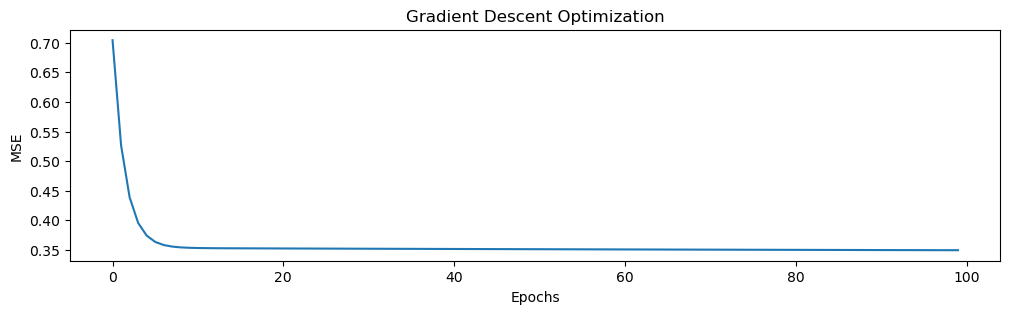

In [21]:
# Plot MSE curve
plt.figure(figsize=(12,3))
plt.plot(range(len(mse_gd)), mse_gd)
plt.title('Gradient Descent Optimization')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.show()

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| *(General Code)* | Implements the formula or logic defined in the preceding markdown text. |


📖 **READ**

## Stage-03 -- Stochastic Gradient Descent

✏️ **TODO**

- SGD works almost the same as Gradient Descent, it picks only one sample to update `m` and `b` parameters
- Make change to sample size (`batch_size`), sometimes its better to use more than one sample at a time.

In [24]:
# Set the parameters lr=0.01, epoch=100 and batch size=2,  also set m = 0.5 together with b = 0.5

# Convert X and y to numpy arrays
X_np, y_np = np.array(X), np.array(y)

# Set the m, b parameters
m_sgd, b_sgd = 0.5, 0.5

# Build a list to store learning process
log_sgd, mse_sgd = [], []

np.random.seed(42)

for epoch in range(100):
    # Randomly sampling
    idx = np.random.randint(0, len(X_np), 2)
    X_batch, y_batch = X_np[idx], y_np[idx]
    N = len(X_batch)
    
    # Compute error and update parameters
    error = y_batch - (m_sgd * X_batch + b_sgd)
    m_sgd -= 0.01 * (-2 * X_batch.dot(error).sum() / N)
    b_sgd -= 0.01 * (-2 * error.sum() / N)
    
    log_sgd.append((m_sgd, b_sgd))
    mse_sgd.append(mean_squared_error(y, m_sgd*X + b_sgd))

y_pred_sgd = m_sgd * X + b_sgd

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `['MedInc']` | Extracts a single column named 'MedInc' from the pandas DataFrame, returning a pandas 'Series'. |
| `np.array(...)` | Converts the pandas Series into a NumPy array. NumPy arrays are highly optimized for mathematical computations (like those in Gradient Descent) and do not have the overhead of pandas indices. |
| `error = ...` | Calculates the residuals (difference between true y and predicted y). |
| `** 2` | The Python operator for exponentiation. `** 2` squares the values. We square errors so that negative errors and positive errors don't cancel each other out when we sum them. |
| `sum(...)` | Sums all the values in an array/list. |
| `len(...)` | Returns the total number of items in an array. By dividing the sum of squared errors by the length, we get the 'Mean' Squared Error. |
| `np.random.randint(0, n)` | Generates a random integer between 0 (inclusive) and `n` (exclusive). In Stochastic Gradient Descent (SGD), we use this to pick one random data point at each step instead of using the entire dataset. |
| `x[random_index]` | Uses standard array indexing to extract the randomly chosen feature value. |
| `np.random.seed(42)` | Initializes the random number generator with a specific "seed" value (42 is common by convention). This ensures that every time you run the code, the "random" numbers generated are exactly the same, which makes our results reproducible. |


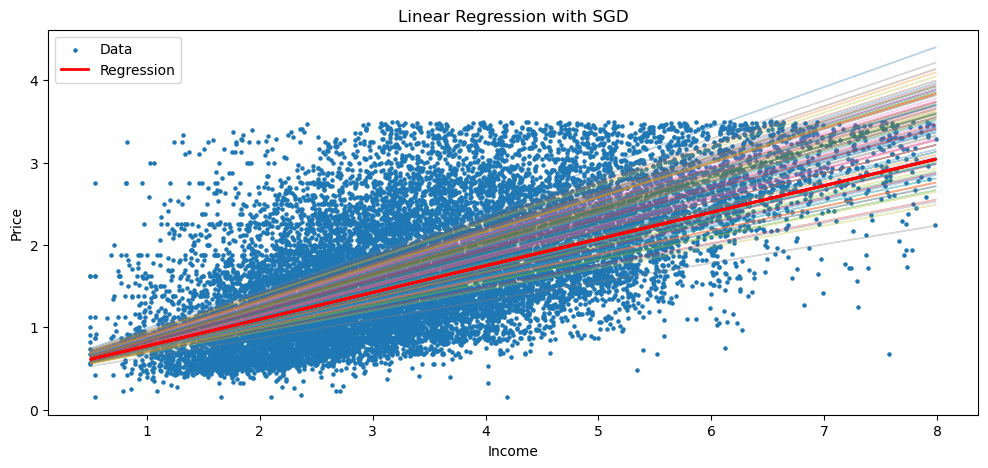

SGD MSE: 0.3648500017361


In [25]:
# Plot SGD results
plt.figure(figsize=(12,5))
plt.scatter(X, y, label='Data', s=5)
for i in range(len(log_sgd)):
    plt.plot(X, log_sgd[i][0]*X + log_sgd[i][1], lw=1, alpha=0.3)
plt.plot(X, y_pred_sgd, 'r', lw=2, label='Regression')
plt.title("Linear Regression with SGD")
plt.xlabel('Income')
plt.ylabel('Price')
plt.legend()
plt.show()
print("SGD MSE:", mean_squared_error(y, y_pred_sgd))

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `plt.scatter(x, y)` | Calls the `scatter` function from Matplotlib's `pyplot` module to create a scatter plot. The first argument is the X-axis array, the second is the Y-axis. |
| `plt.xlabel(...)` | Sets the text label for the X-axis. |
| `plt.ylabel(...)` | Sets the text label for the Y-axis. |
| `plt.title(...)` | Sets the title text displayed at the top of the plot. |
| `plt.show()` | Actually renders and displays the plot to the screen. In Jupyter, plots often render automatically, but explicitly calling `show()` suppresses messy object output texts. |


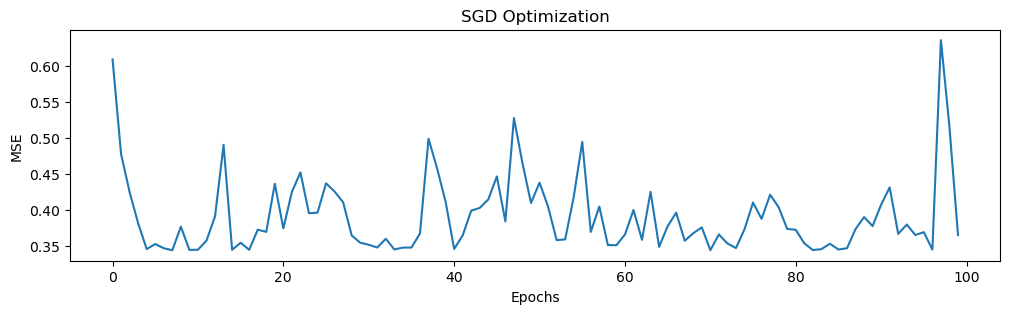

In [26]:
# Plot MSE curve of SGD
plt.figure(figsize=(12,3))
plt.plot(range(len(mse_sgd)), mse_sgd)
plt.title('SGD Optimization')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.show()

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| *(General Code)* | Implements the formula or logic defined in the preceding markdown text. |


---

## Summary of Functions and Methods
| Method/Function | Category | Explanation |
|---|---|---|
| `fetch_california_housing` | Data Loading | Fetches the California Housing dataset from the Scikit-Learn archive. |
| `pd.DataFrame()` | Pandas | Instantiates a 2-dimensional labeled data structure with columns of potentially different types. |
| `df.describe()` | Pandas | Returns a summary profile of all the descriptive statistics for a pandas DataFrame. |
| `reset_index(drop=True)` | Pandas | Resets the index of a DataFrame and drops the existing one to maintain a clean sequence. |
| `np.array()` | NumPy | Creates a new multidimensional NumPy array from another data structure. |
| `np.mean()` | NumPy | Computes the arithmetic mean along the specified axis. |
| `plt.scatter()` | Matplotlib | Renders a scatter plot using x vs y coordinates. |
| `plt.plot()` | Matplotlib | Renders a line graph connecting provided coordinate pairs. |
| `def` / `return` | Python Core | Standard keywords used to define reusable functions and return computed values. |
